In [2]:
import pandas as pd
import numpy as np
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv("heart.csv")
df.head(5)

,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall,output
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [6]:
df.shape

(303, 14)

In [7]:
df.isnull().sum().to_frame()

,0
age,0
sex,0
cp,0
trtbps,0
chol,0
fbs,0
restecg,0
thalachh,0
exng,0
oldpeak,0


In [8]:
all(df.duplicated())

False

In [9]:
df.dtypes.to_frame()

,0
age,int64
sex,int64
cp,int64
trtbps,int64
chol,int64
fbs,int64
restecg,int64
thalachh,int64
exng,int64
oldpeak,float64


In [10]:
np.linalg.matrix_rank(df)

np.int64(14)

array([[<Axes: title={'center': 'age'}>, <Axes: title={'center': 'sex'}>,
        <Axes: title={'center': 'cp'}>,
        <Axes: title={'center': 'trtbps'}>],
       [<Axes: title={'center': 'chol'}>,
        <Axes: title={'center': 'fbs'}>,
        <Axes: title={'center': 'restecg'}>,
        <Axes: title={'center': 'thalachh'}>],
       [<Axes: title={'center': 'exng'}>,
        <Axes: title={'center': 'oldpeak'}>,
        <Axes: title={'center': 'slp'}>, <Axes: title={'center': 'caa'}>],
       [<Axes: title={'center': 'thall'}>,
        <Axes: title={'center': 'output'}>, <Axes: >, <Axes: >]],
      dtype=object)

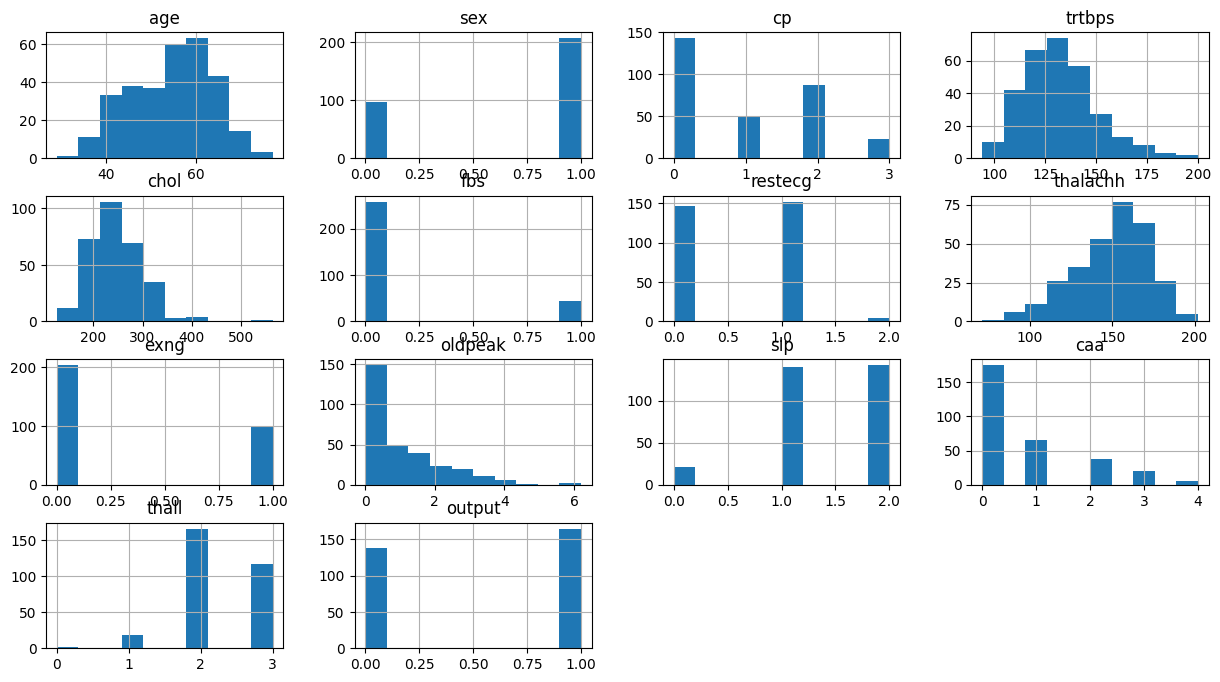

In [11]:
df.hist(figsize=(15,8))

In [12]:
def find_replace_outliers_IQR(df_col: pd.Series) -> pd.Series:
     q1 = df_col.quantile(0.25)

     q3 = df_col.quantile(0.75)

     IQR = q3-q1

     median_value = df_col.median()

     cond=((df_col < (q1-1.5*IQR)) | (df_col > (q3+1.5*IQR)))

     df_col=np.where(cond,median_value,df_col)


     return df_col

In [13]:
for column in df:
     data[column]=find_replace_outliers_IQR(df[column])

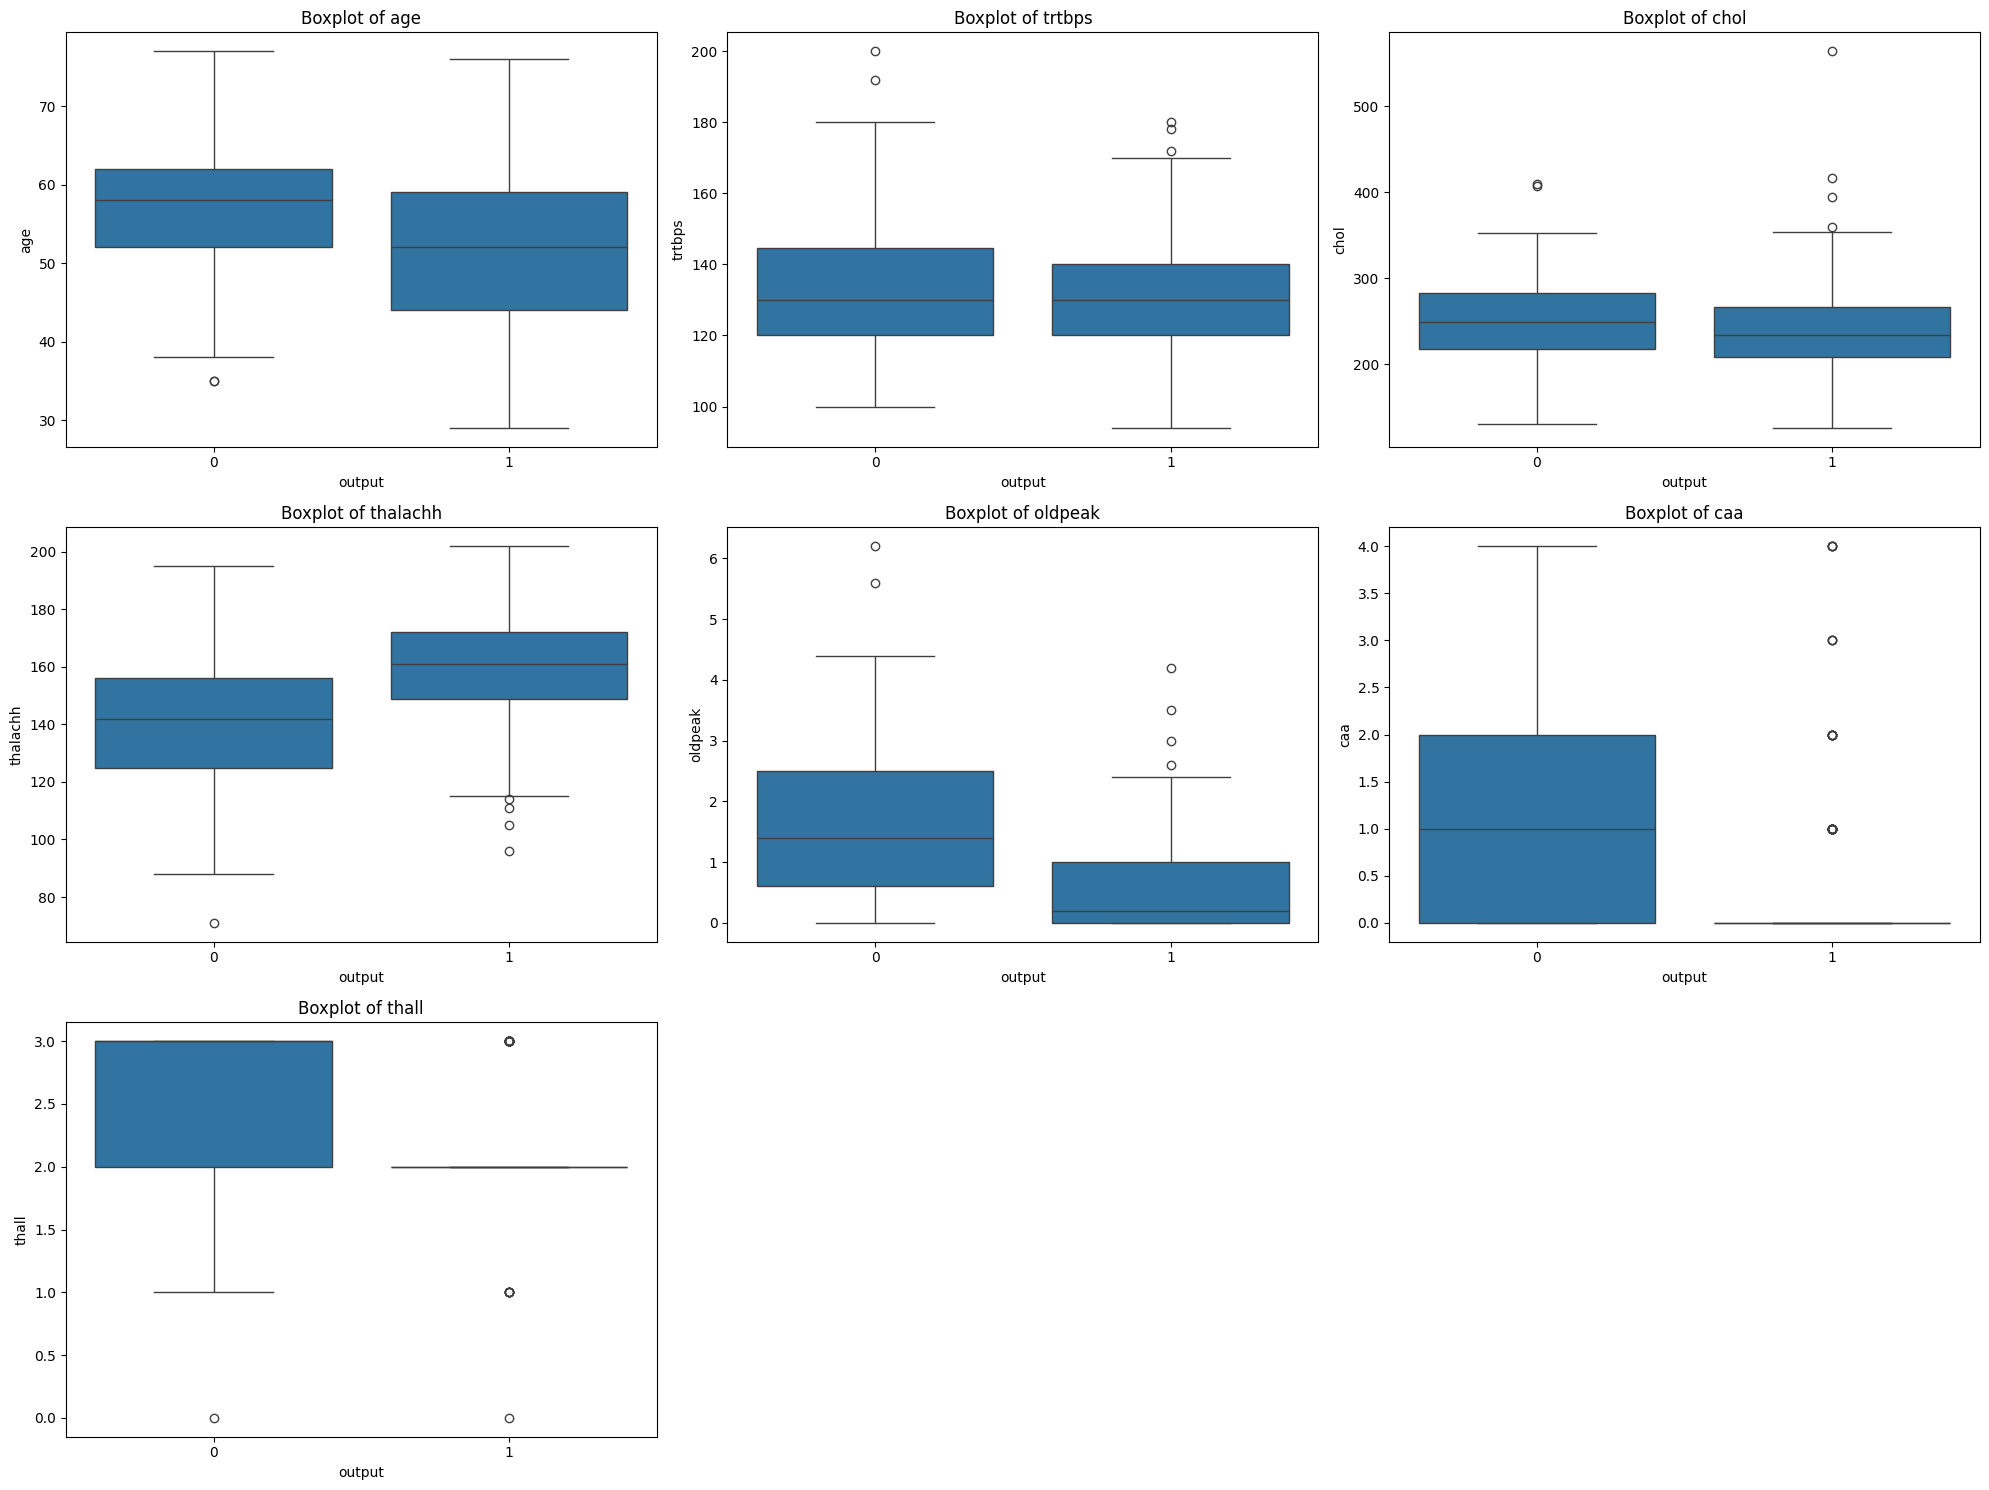

In [21]:

plt.figure(figsize=(20, 15))
df_boxplot = df.drop(['sex','cp', 'restecg', 'exng', 'slp', 'fbs'], axis=1) #dropping descrete columns for boxplot
for i, column in enumerate(df_boxplot.columns[:-1]):  
    plt.subplot(3, 3, i + 1)
    sns.boxplot(x='output', y=column, data=df_boxplot)
    plt.title('Boxplot of {}'.format(column))
    plt.tight_layout()

plt.show()

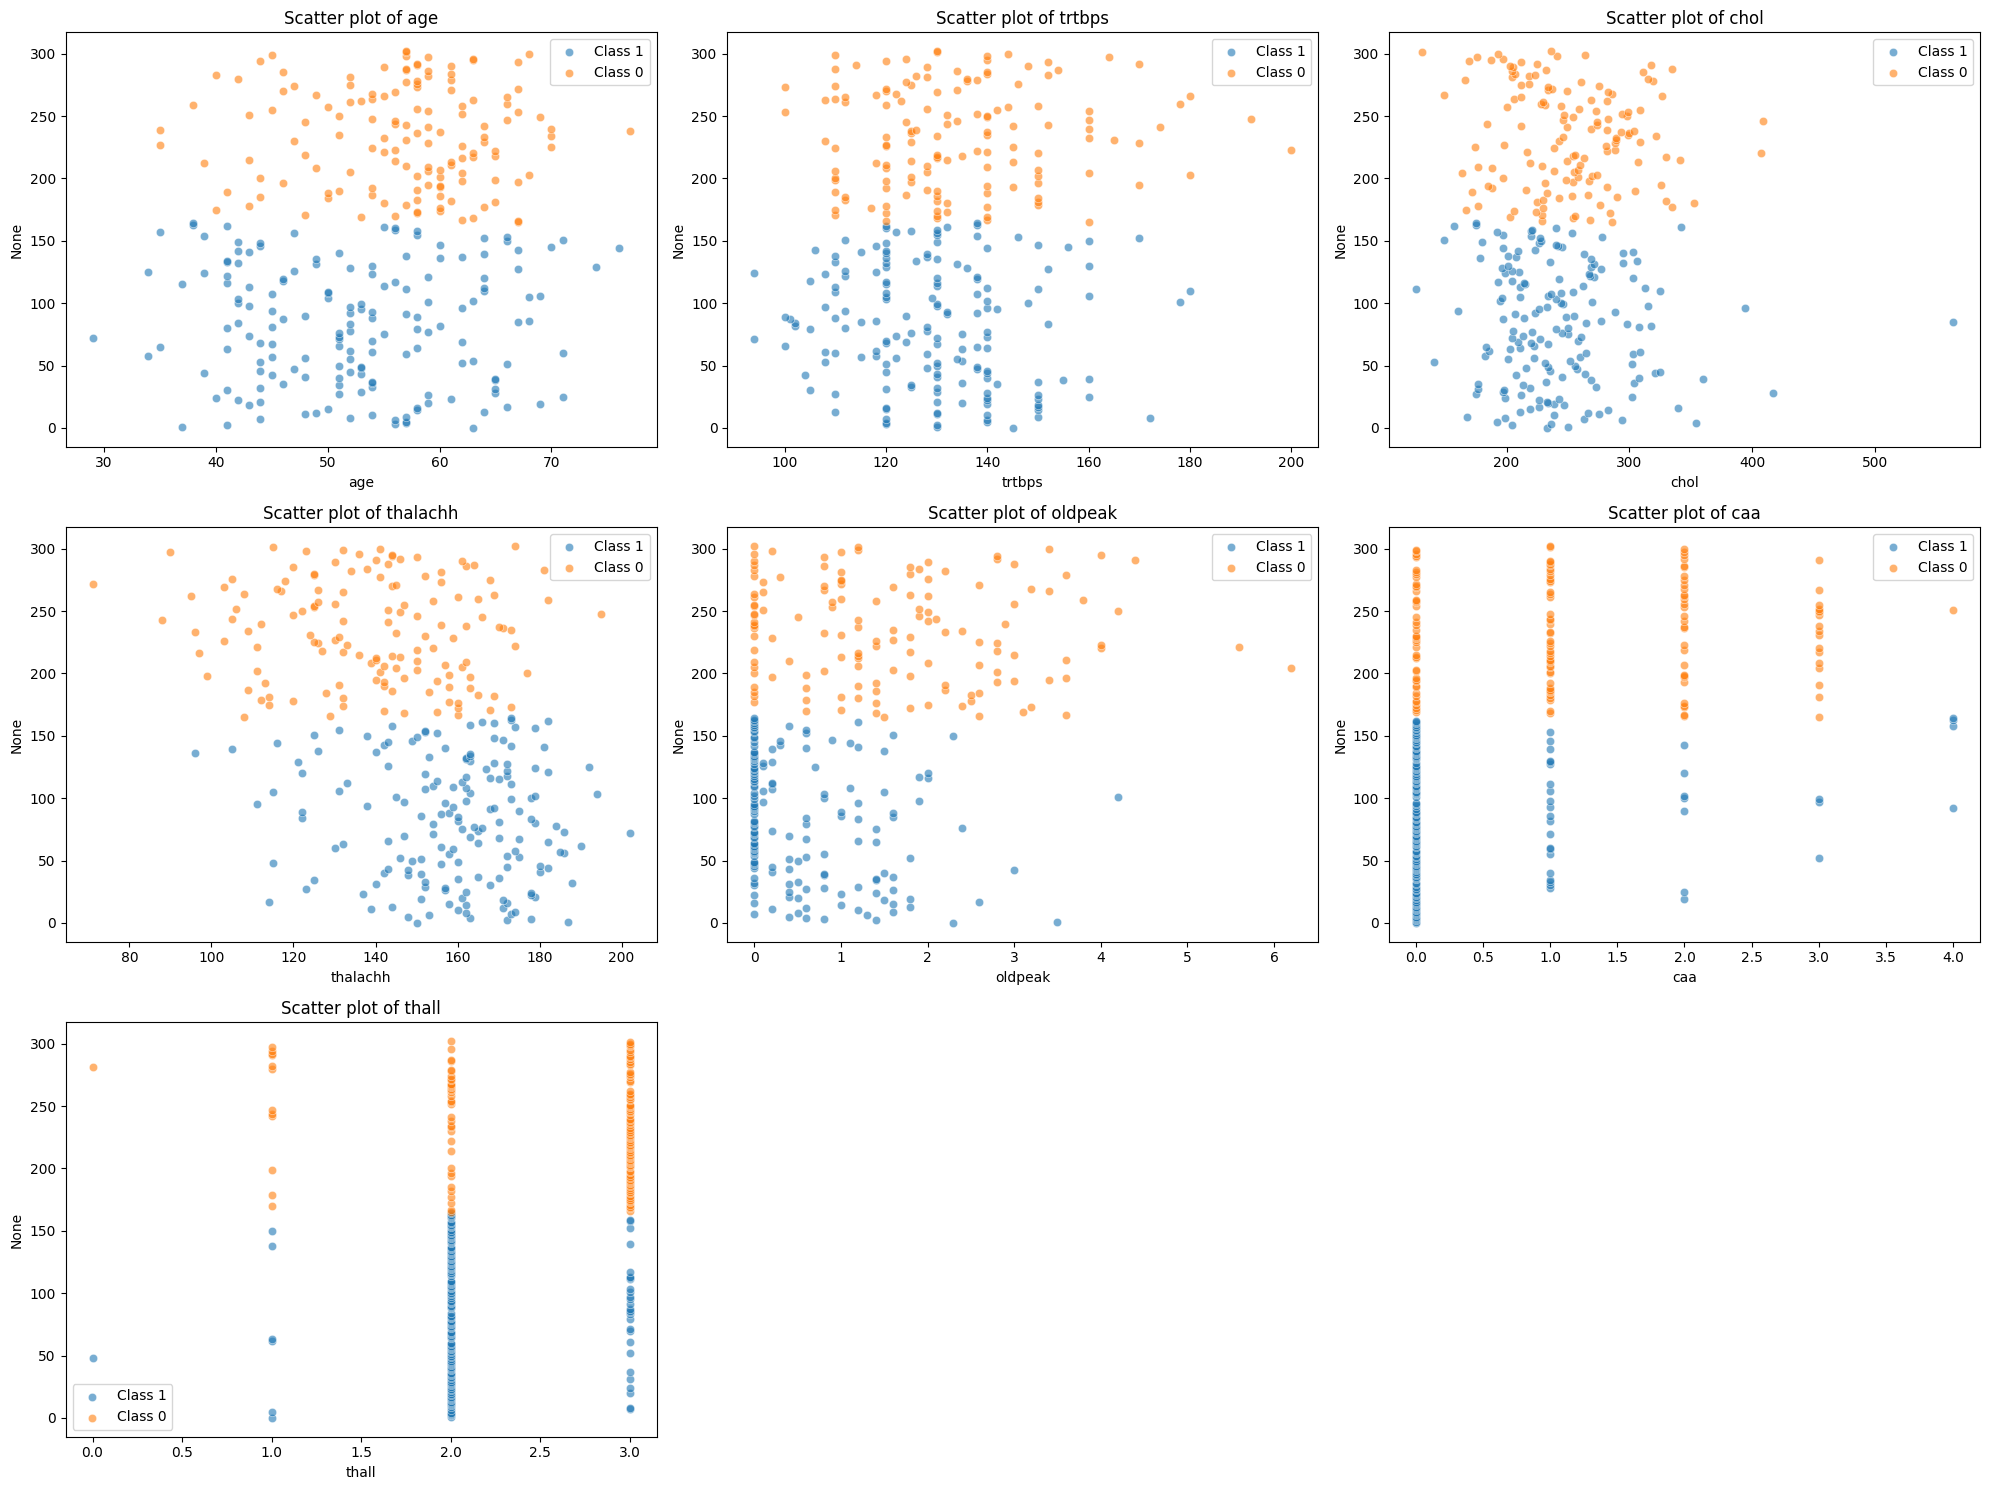

In [23]:
plt.figure(figsize=(20, 15))


output = df['output'].unique()
for i, column in enumerate(df_boxplot.columns[:-1]):  # Excluding the 'class' column
    plt.subplot(3, 3, i + 1)
    
    # Create scatter plot for each class
    for j in output:
        subset = df_boxplot[df_boxplot['output'] == j]
        sns.scatterplot(x=column, y=subset.index, label=f'Class {j}', data=subset, alpha=0.6)

    plt.title('Scatter plot of {}'.format(column))
    plt.legend()
    plt.tight_layout()

plt.show()